# NB06 — LOPO-CV: Predicción Multimodal de Severidad Nocturna

**Pipeline:** PAC_v2 · Gold v1.2  
**Cohorte:** cohort_strict (pacientes con ≥10 noches in_strict)  
**Depende de:** NB03 (night_features), NB04 (night_multiscale_features), NB05 (coupling_index)

### Objetivo
Evaluar si las features PAC (estados S/M/L, morfotipos, ARI) permiten predecir
la **categoría de severidad AASM nocturna** usando validación cruzada
Leave-One-Patient-Out (LOPO-CV) con Random Forest.

### Diseño
- Un fold por paciente (dejar un paciente fuera como test)
- RandomForest con class_weight='balanced' (clases desbalanceadas)
- Ablation study por grupo de features
- Importancia Gini + SHAP multiclase

## Sección 0 — Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib
try:
    get_ipython()           # Jupyter → backend inline, no cambiar
except NameError:
    matplotlib.use('Agg')  # Headless / CI
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             cohen_kappa_score, classification_report,
                             confusion_matrix, f1_score)
from matplotlib.patches import Patch

try:
    import shap
    SHAP_OK = True
except ImportError:
    SHAP_OK = False
    print("⚠ shap no instalado — celda SHAP se omitirá")

ROOT    = Path('..')
GOLD    = ROOT / 'gold'
FIGDIR  = Path('figuras')
FIGDIR.mkdir(exist_ok=True)

plt.rcParams.update({'figure.dpi': 150, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.labelsize': 11, 'figure.facecolor': 'white', 'axes.facecolor': '#F8F8F8'})

SEV_ORDER  = ['Normal', 'Leve', 'Moderado', 'Severo']
SEV_COLORS = {'Normal':'#2ecc71','Leve':'#f1c40f','Moderado':'#e67e22','Severo':'#e74c3c'}
SCALE_C    = {'S':'#3498db','M':'#9b59b6','L':'#e67e22'}
GRP_C      = {'PAC States (S/M/L)':'#3498db','PAC Dynamics':'#1abc9c',
              'Morfotipos C1-C5':'#27ae60','ARI':'#e74c3c',
              'Sueño':'#8e44ad','Clínico':'#95a5a6'}
TARGET_MAP = {'Normal':0,'Leve':1,'Moderado':2,'Severo':3}
INT2SEV    = {v:k for k,v in TARGET_MAP.items()}

def savefig(name):
    plt.tight_layout()
    plt.savefig(FIGDIR / name, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  → {FIGDIR / name}')

print(f'GOLD  : {GOLD.resolve()}')
print(f'SHAP  : {SHAP_OK}')
print('Setup OK ✓')

⚠ shap no instalado — celda SHAP se omitirá
GOLD  : /Users/ri1965/Proyectos/PAC_v2/gold
SHAP  : False
Setup OK ✓


## Sección 1 — Preparación de features y target

In [2]:
nmf = pd.read_parquet(GOLD / 'night_multiscale_features.parquet')
nf  = pd.read_parquet(GOLD / 'night_features.parquet')
pts = pd.read_parquet(GOLD / 'patients.parquet')

# ── features por grupo ────────────────────────────────────────────────────────
MORPHO = ['frac_c1','frac_c2','frac_c3','frac_c4','frac_c5','frac_severe_morpho']
SLEEP  = ['sleep_efficiency','tst_s','waso_s']
ARI_F  = ['mean_ari','p90_ari','std_ari']
PAC_S  = [f'frac_state_s_S{i}' for i in range(6)]   # S0–S5
PAC_M  = [f'frac_state_m_M{i}' for i in range(5)]   # M0–M4
PAC_L  = [f'frac_state_l_L{i}' for i in range(6)]   # L0–L5
PAC_D  = ['entropy_state_s','entropy_state_m','entropy_state_l',
          'n_transitions_state_s','n_transitions_state_m','n_transitions_state_l']
CLIN   = [c for c in ['sexo_bin','bmi','apnea_prev','diabetes','hta','marcapasos']
          if c in pts.columns or c in ['sexo_bin','bmi']]
ALL_F  = PAC_S + PAC_M + PAC_L + PAC_D + MORPHO + ARI_F + SLEEP + CLIN

GROUPS = {'PAC States (S/M/L)': PAC_S+PAC_M+PAC_L, 'PAC Dynamics': PAC_D,
          'Morfotipos C1-C5': MORPHO, 'ARI': ARI_F, 'Sueño': SLEEP, 'Clínico': CLIN}
f2g    = {f: g for g, fs in GROUPS.items() for f in fs}

# ── construir variables clínicas en pts ──────────────────────────────────────
pts['bmi']      = pts['peso_kg'] / (pts['talla_cm'] / 100) ** 2
pts['sexo_bin'] = (pts['sexo'] == 'M').astype(int)
clin_cols = ['user_id','sexo_bin','bmi'] + [c for c in ['apnea_prev','diabetes','hta','marcapasos']
                                             if c in pts.columns]

# ── cohort_strict: pacientes con >=10 noches in_strict ───────────────────────
# night_features tiene user_id + in_strict
nf_ids  = nf[['night_record_id','user_id','in_strict']].copy()
pat_n   = nf_ids[nf_ids['in_strict']].groupby('user_id').size()
strict_patients = pat_n[pat_n >= 10].index.tolist()
print(f"Pacientes con ≥10 noches in_strict: {len(strict_patients)}")
print(f"  {sorted(strict_patients)}")

# ── nf_sub: features de night_features que no están en nmf ───────────────────
nf_sub = nf[['night_record_id'] + MORPHO + SLEEP + ['std_ari']].copy()

# ── construir df maestro ──────────────────────────────────────────────────────
df = (nmf
      .merge(nf_ids[['night_record_id','user_id','in_strict']], on='night_record_id', how='left')
      .merge(nf_sub, on='night_record_id', how='left')
      .merge(pts[clin_cols], on='user_id', how='left'))

# Filtrar cohort_strict
df = df[df['in_strict'] & df['user_id'].isin(strict_patients)].copy()
df['user_id'] = df['user_id'].astype(str)

# Imputar medianas para features con nulos
for col in ALL_F:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

df['y'] = df['aasm_sev'].map(TARGET_MAP)
PATIENTS = sorted(df['user_id'].unique())

print(f"\nCohort strict: {len(df)} noches, {len(PATIENTS)} pacientes")
print("Distribución target:")
print(df['aasm_sev'].value_counts().reindex(SEV_ORDER).to_string())
print(f"\nFeatures totales: {len(ALL_F)}")
for g, fs in GROUPS.items():
    avail = [f for f in fs if f in df.columns]
    print(f"  {g}: {len(avail)}/{len(fs)}")

Pacientes con ≥10 noches in_strict: 8
  ['175', '240', '309', '314', '321', '336', '656', '683']

Cohort strict: 540 noches, 8 pacientes
Distribución target:
aasm_sev
Normal       41
Leve        326
Moderado    148
Severo       25

Features totales: 44
  PAC States (S/M/L): 15/20
  PAC Dynamics: 6/6
  Morfotipos C1-C5: 6/6
  ARI: 3/3
  Sueño: 3/3
  Clínico: 6/6


## Sección 2 — Análisis exploratorio

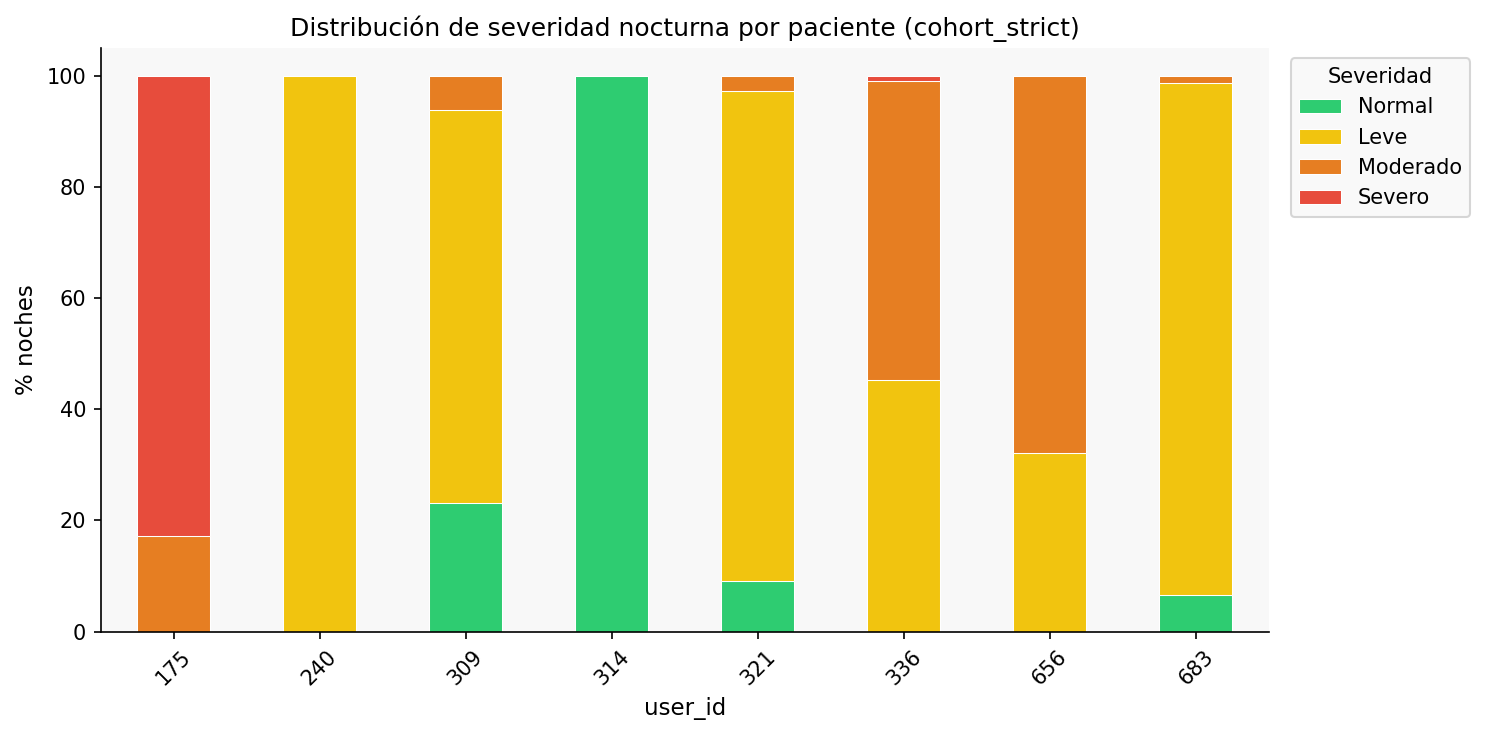

  → figuras/06_distribucion_target_por_paciente.png
Notas metodológicas:
  Normal: 41 noches, paciente(s): ['309', '314', '321', '683']
  Leve: 326 noches, paciente(s): ['240', '309', '321', '336', '656', '683']
  Moderado: 148 noches, paciente(s): ['175', '309', '321', '336', '656', '683']
  Severo: 25 noches, paciente(s): ['175', '336']
  En LOPO, al dejar fuera pacientes mono-clase el modelo no ve esa clase en training


In [3]:
# Distribución target por paciente
piv = df.groupby(['user_id','aasm_sev']).size().unstack(fill_value=0).reindex(columns=SEV_ORDER, fill_value=0)
(piv.div(piv.sum(1), axis=0) * 100).plot(
    kind='bar', stacked=True, figsize=(10, 5),
    color=[SEV_COLORS[s] for s in SEV_ORDER], edgecolor='white', linewidth=0.5)
plt.title('Distribución de severidad nocturna por paciente (cohort_strict)')
plt.ylabel('% noches'); plt.xticks(rotation=45)
plt.legend(title='Severidad', bbox_to_anchor=(1.01, 1))
savefig('06_distribucion_target_por_paciente.png')

gd = df['aasm_sev'].value_counts().reindex(SEV_ORDER)
print("Notas metodológicas:")
for sev in SEV_ORDER:
    pats = df[df['aasm_sev']==sev]['user_id'].unique()
    print(f"  {sev}: {gd[sev]} noches, paciente(s): {sorted(pats)}")
print("  En LOPO, al dejar fuera pacientes mono-clase el modelo no ve esa clase en training")

In [4]:
# Kruskal-Wallis: asociación features vs severidad
from scipy.stats import kruskal
kw = {}
for feat in ALL_F:
    if feat not in df.columns:
        continue
    grps = [df[df['aasm_sev']==s][feat].dropna().values for s in SEV_ORDER if (df['aasm_sev']==s).any()]
    try:
        H, p = kruskal(*grps)
        kw[feat] = (H, p)
    except:
        kw[feat] = (np.nan, 1.0)

kw_df = pd.DataFrame(kw, index=['H','p']).T.sort_values('H', ascending=False)
print("Top-15 features por H (Kruskal-Wallis):")
print(kw_df.head(15)[['H','p']].round(2).to_string())

Top-15 features por H (Kruskal-Wallis):
                            H    p
n_transitions_state_s  248.29  0.0
frac_state_s_S3        215.11  0.0
frac_state_s_S4        210.61  0.0
frac_c2                197.04  0.0
frac_c1                180.62  0.0
frac_state_l_L3        171.32  0.0
frac_state_l_L0        163.55  0.0
waso_s                 157.28  0.0
frac_state_m_M1        156.96  0.0
sleep_efficiency       153.13  0.0
frac_state_m_M0        149.88  0.0
hta                    144.57  0.0
frac_state_m_M2        135.27  0.0
frac_state_m_M3        123.76  0.0
frac_state_s_S1        116.79  0.0


## Sección 3 — LOPO-CV con Random Forest

**Diseño:** N folds (un paciente dejado fuera por fold).  
RF con hiperparámetros fijos: `n_estimators=300, class_weight='balanced', max_depth=15`.

In [5]:
lopo_res = []; ytrue = []; ypred = []
yproba = []; pat_ids = []; nids = []; fold_fi = []

for tp in PATIENTS:
    tm = df['user_id'] == tp
    feat_cols = [f for f in ALL_F if f in df.columns]

    Xtr = df.loc[~tm, feat_cols].values
    ytr = df.loc[~tm, 'y'].values
    Xte = df.loc[ tm, feat_cols].values
    yte = df.loc[ tm, 'y'].values
    nid = df.loc[ tm, 'night_record_id'].values
    ts  = df.loc[ tm, 'aasm_sev'].mode()[0]

    rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                max_depth=15, min_samples_leaf=2,
                                random_state=42, n_jobs=-1)
    rf.fit(Xtr, ytr)
    yp  = rf.predict(Xte)
    pr  = rf.predict_proba(Xte)
    pf  = np.zeros((len(yte), 4))
    for j, c in enumerate(rf.classes_):
        pf[:, c] = pr[:, j]

    acc = accuracy_score(yte, yp)
    ba  = balanced_accuracy_score(yte, yp)
    k   = cohen_kappa_score(yte, yp) if len(np.unique(yte)) > 1 else np.nan
    f1  = f1_score(yte, yp, average='weighted', zero_division=0)

    ytrue.extend(yte.tolist()); ypred.extend(yp.tolist())
    yproba.extend(pf.tolist()); pat_ids.extend([tp]*len(yte)); nids.extend(nid.tolist())
    fold_fi.append(rf.feature_importances_)
    lopo_res.append({'patient':tp,'dominant_sev':ts,'n_nights':len(yte),
                     'acc':acc,'bal_acc':ba,'kappa':k,'f1_weighted':f1})
    print(f"Pac {tp:5s} ({ts:8s}, {len(yte):3d}n)  Acc={acc:.3f}  BalAcc={ba:.3f}  κ={k:.3f}  F1={f1:.3f}")

lopo_df = pd.DataFrame(lopo_res)
yta = np.array(ytrue); ypa = np.array(ypred)
ALL_F_AVAIL = [f for f in ALL_F if f in df.columns]

Pac 175   (Severo  ,  29n)  Acc=0.172  BalAcc=0.500  κ=0.000  F1=0.051
Pac 240   (Leve    ,  28n)  Acc=1.000  BalAcc=1.000  κ=nan  F1=1.000
Pac 309   (Leve    ,  65n)  Acc=0.769  BalAcc=0.483  κ=0.288  F1=0.710
Pac 314   (Normal  ,  11n)  Acc=0.182  BalAcc=0.182  κ=nan  F1=0.308
Pac 321   (Leve    , 109n)  Acc=0.908  BalAcc=0.523  κ=0.503  F1=0.894
Pac 336   (Moderado, 117n)  Acc=0.453  BalAcc=0.333  κ=0.046  F1=0.295
Pac 656   (Moderado, 106n)  Acc=0.330  BalAcc=0.507  κ=0.009  F1=0.176
Pac 683   (Leve    ,  75n)  Acc=0.920  BalAcc=0.457  κ=0.366  F1=0.914


In [6]:
# Métricas globales
g_acc  = accuracy_score(yta, ypa)
g_bacc = balanced_accuracy_score(yta, ypa)
g_k    = cohen_kappa_score(yta, ypa)
g_f1   = f1_score(yta, ypa, average='weighted', zero_division=0)
print(f"Global Accuracy:          {g_acc:.3f}")
print(f"Global Balanced Accuracy: {g_bacc:.3f}")
print(f"Global Cohen kappa:       {g_k:.3f}")
print(f"Global F1 weighted:       {g_f1:.3f}")
print(f"\nFold mean BalAcc: {lopo_df['bal_acc'].mean():.3f} ± {lopo_df['bal_acc'].std():.3f}")
print(f"Fold mean kappa:  {lopo_df['kappa'].mean():.3f} ± {lopo_df['kappa'].std():.3f}")
display(lopo_df[['patient','dominant_sev','n_nights','acc','bal_acc','kappa','f1_weighted']].round(3))

Global Accuracy:          0.631
Global Balanced Accuracy: 0.337
Global Cohen kappa:       0.162
Global F1 weighted:       0.534

Fold mean BalAcc: 0.498 ± 0.234
Fold mean kappa:  0.202 ± 0.213


,patient,dominant_sev,n_nights,acc,bal_acc,kappa,f1_weighted
0,175,Severo,29,0.172,0.500,0.000,0.051
1,240,Leve,28,1.000,1.000,NaN,1.000
2,309,Leve,65,0.769,0.483,0.288,0.710
3,314,Normal,11,0.182,0.182,NaN,0.308
4,321,Leve,109,0.908,0.523,0.503,0.894
5,336,Moderado,117,0.453,0.333,0.046,0.295
6,656,Moderado,106,0.330,0.507,0.009,0.176
7,683,Leve,75,0.920,0.457,0.366,0.914


## Sección 4 — Matriz de confusión y reporte

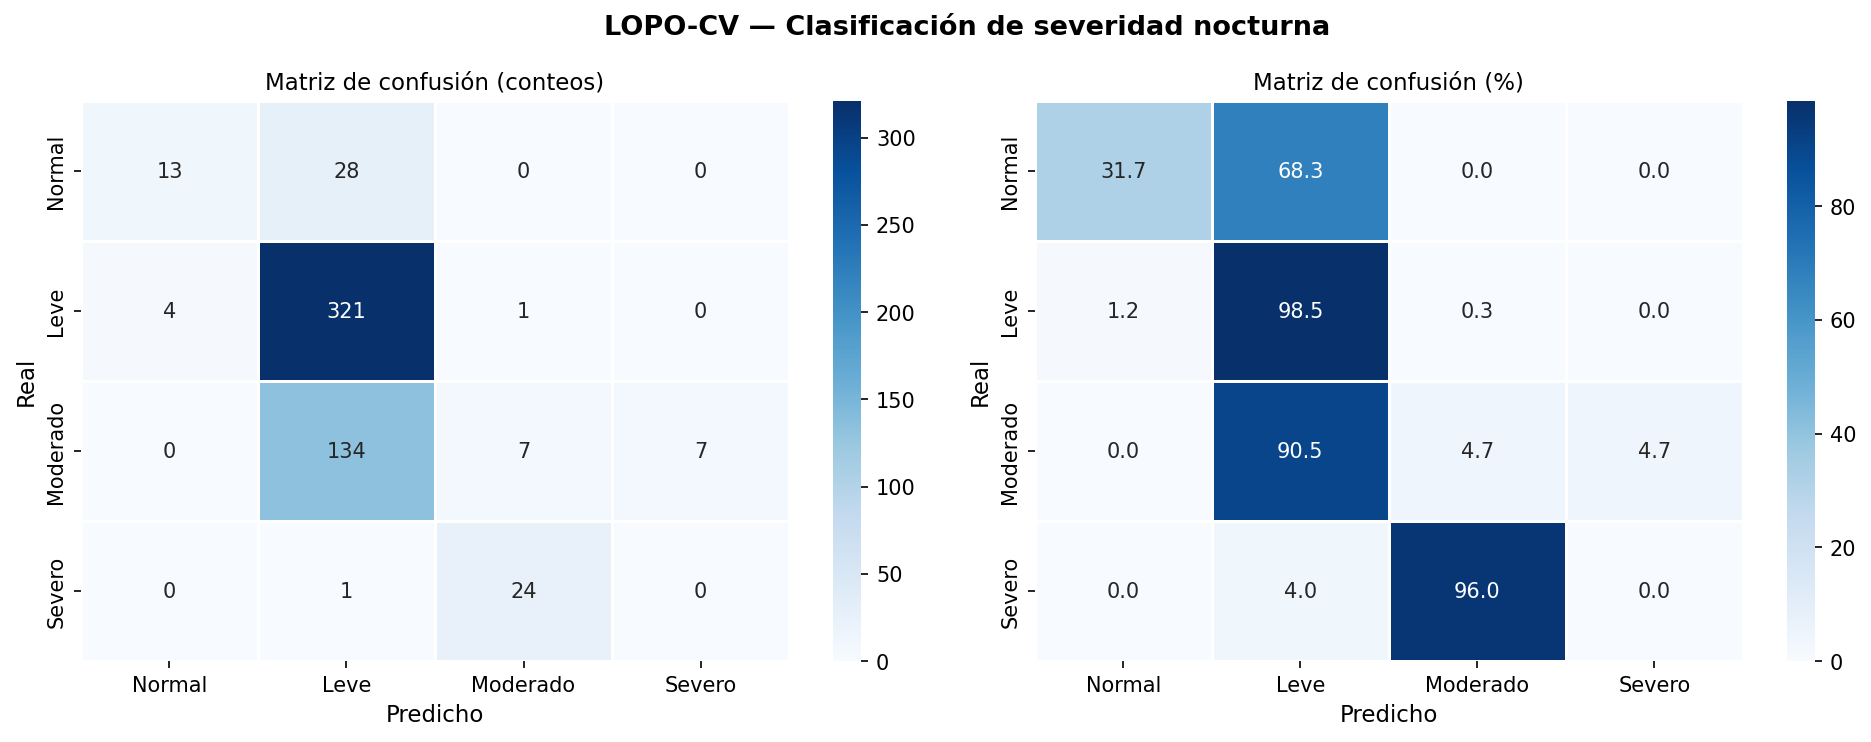

  → figuras/06_confusion_matrix.png

Classification report:
              precision    recall  f1-score   support

      Normal       0.76      0.32      0.45        41
        Leve       0.66      0.98      0.79       326
    Moderado       0.22      0.05      0.08       148
      Severo       0.00      0.00      0.00        25

    accuracy                           0.63       540
   macro avg       0.41      0.34      0.33       540
weighted avg       0.52      0.63      0.53       540



In [7]:
SEV_INT = [TARGET_MAP[s] for s in SEV_ORDER]
cm     = confusion_matrix(yta, ypa, labels=SEV_INT)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, mat, title, fmt in zip(axes, [cm, cm_pct],
    ['Matriz de confusión (conteos)', 'Matriz de confusión (%)'], ['d', '.1f']):
    sns.heatmap(mat, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=SEV_ORDER, yticklabels=SEV_ORDER,
                linewidths=0.5, linecolor='white')
    ax.set_xlabel('Predicho'); ax.set_ylabel('Real')
    ax.set_title(title, fontsize=11)
plt.suptitle('LOPO-CV — Clasificación de severidad nocturna', fontsize=13, fontweight='bold')
savefig('06_confusion_matrix.png')

print("\nClassification report:")
print(classification_report(yta, ypa, target_names=SEV_ORDER, zero_division=0))

## Sección 5 — Importancia de features (RF Gini + SHAP)

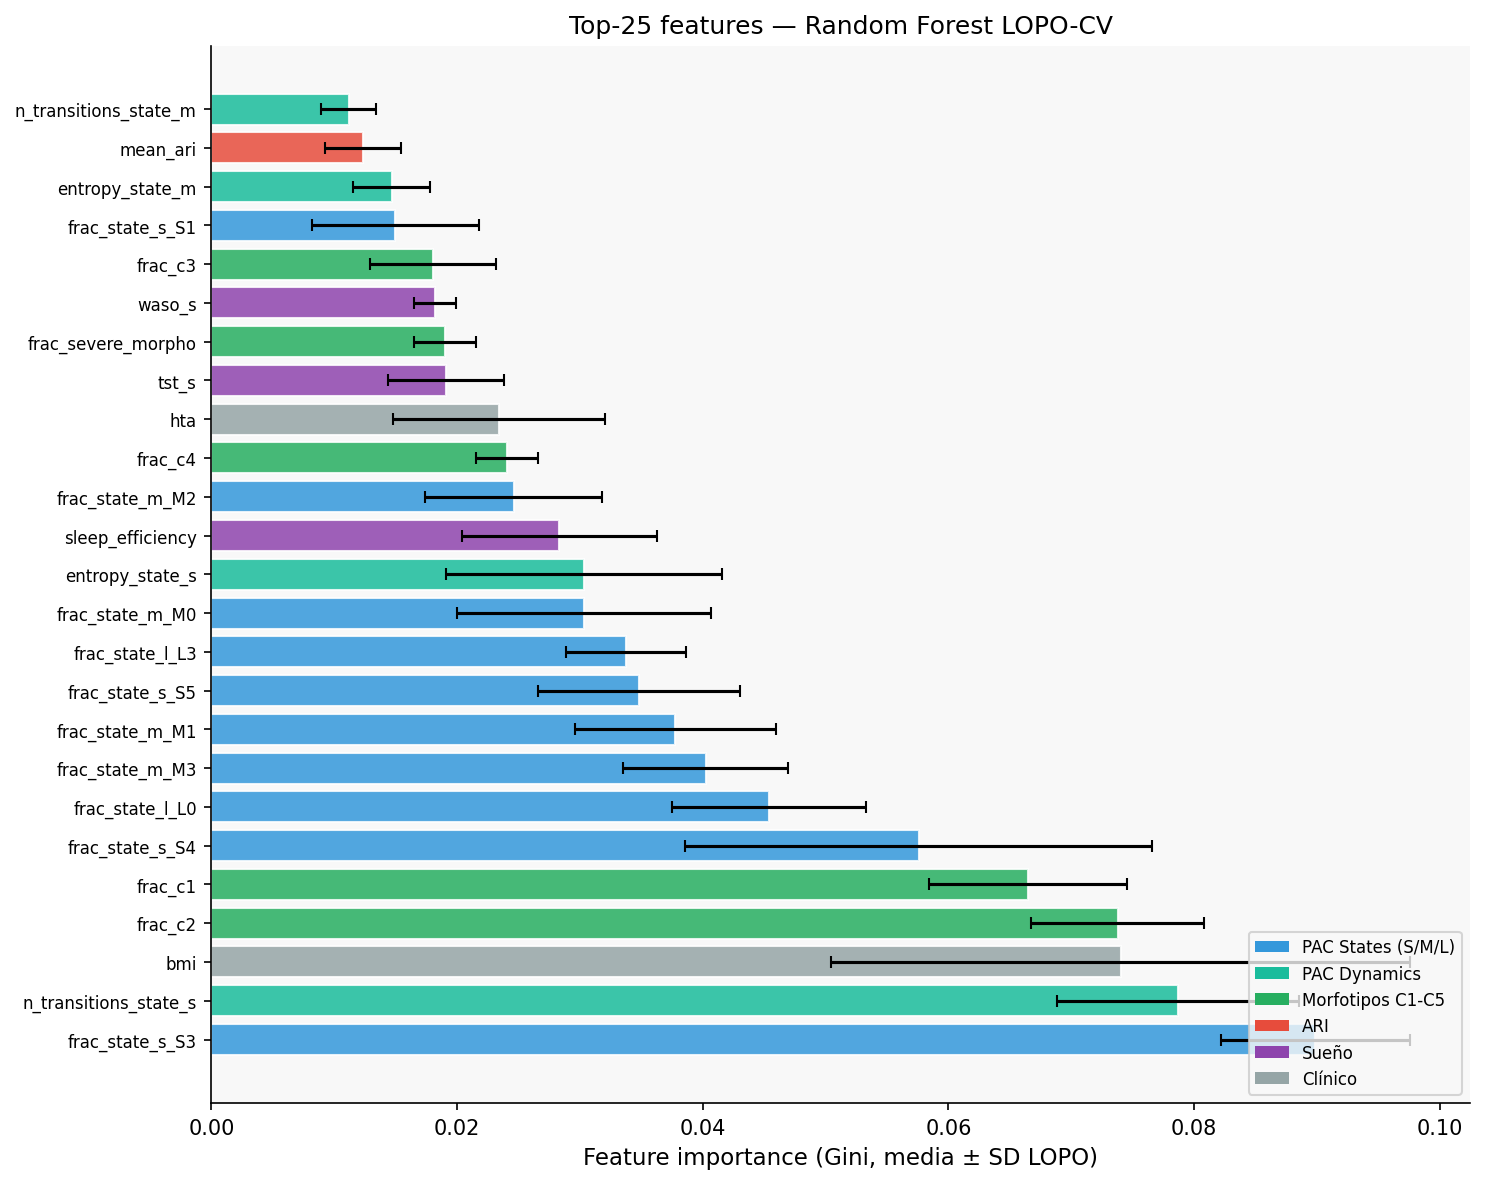

  → figuras/06_feature_importance_gini.png

Importancia por grupo:
             group  importance_mean
PAC States (S/M/L)         0.448497
  Morfotipos C1-C5         0.205662
      PAC Dynamics         0.147012
           Clínico         0.100692
             Sueño         0.065616
               ARI         0.032521


In [8]:
fi_mat = np.array(fold_fi)
fi_df  = pd.DataFrame({
    'feature':          ALL_F_AVAIL,
    'importance_mean':  fi_mat.mean(0),
    'importance_std':   fi_mat.std(0),
    'group':            [f2g.get(f, 'Otro') for f in ALL_F_AVAIL]
}).sort_values('importance_mean', ascending=False)

def sc(f):
    if 'state_s' in f or f in ['entropy_state_s','n_transitions_state_s']: return 'S'
    if 'state_m' in f or f in ['entropy_state_m','n_transitions_state_m']: return 'M'
    if 'state_l' in f or f in ['entropy_state_l','n_transitions_state_l']: return 'L'
    return 'Otro'
fi_df['scale'] = fi_df['feature'].apply(sc)

grp_imp = (fi_df.groupby('group')['importance_mean'].sum()
           .reset_index().sort_values('importance_mean', ascending=False))

top25  = fi_df.head(25)
bc25   = [GRP_C.get(g, '#aaa') for g in top25['group']]
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top25)), top25['importance_mean'], xerr=top25['importance_std'],
        color=bc25, edgecolor='white', alpha=0.85, capsize=3)
ax.set_yticks(range(len(top25))); ax.set_yticklabels(top25['feature'], fontsize=8)
ax.set_xlabel('Feature importance (Gini, media ± SD LOPO)')
ax.set_title('Top-25 features — Random Forest LOPO-CV')
ax.legend(handles=[Patch(facecolor=c, label=g) for g, c in GRP_C.items()],
          loc='lower right', fontsize=8)
savefig('06_feature_importance_gini.png')

print("\nImportancia por grupo:")
print(grp_imp.to_string(index=False))

In [9]:
# SHAP (modelo final sobre cohort_strict completa)
if not SHAP_OK:
    print("shap no instalado — omitiendo esta celda.")
else:
    X_all = df[ALL_F_AVAIL].values; y_all = df['y'].values
    rf_f  = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   max_depth=10, random_state=42, n_jobs=-1)
    rf_f.fit(X_all, y_all)
    np.random.seed(42)
    idx_s    = np.random.choice(len(X_all), min(200, len(X_all)), replace=False)
    explainer = shap.TreeExplainer(rf_f)
    shap_v    = explainer.shap_values(X_all[idx_s])
    # API nueva: (samples, features, classes)
    if isinstance(shap_v, list):
        shap_g = np.mean([np.abs(sv) for sv in shap_v], axis=(0,1))
    elif shap_v.ndim == 3:
        shap_g = np.mean(np.abs(shap_v), axis=(0, 2))
    else:
        shap_g = np.mean(np.abs(shap_v), axis=0)

    shap_df = pd.DataFrame({
        'feature': ALL_F_AVAIL,
        'shap_importance': shap_g,
        'group': [f2g.get(f,'Otro') for f in ALL_F_AVAIL]
    }).sort_values('shap_importance', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    top15s = shap_df.head(15)
    axes[0].barh(range(len(top15s)), top15s['shap_importance'],
                 color=[GRP_C.get(g,'#aaa') for g in top15s['group']],
                 edgecolor='white', alpha=0.85)
    axes[0].set_yticks(range(len(top15s))); axes[0].set_yticklabels(top15s['feature'], fontsize=8)
    axes[0].set_xlabel('Mean |SHAP| (multiclase)'); axes[0].set_title('SHAP global — Top-15')
    axes[0].legend(handles=[Patch(facecolor=c, label=g) for g, c in GRP_C.items()],
                   loc='lower right', fontsize=7)

    cmp = pd.DataFrame({
        'RF_Gini': fi_df.set_index('feature')['importance_mean'],
        'SHAP':    shap_df.set_index('feature')['shap_importance']
    }).dropna()
    cmp = (cmp / cmp.max()).sort_values('RF_Gini', ascending=False).head(20)
    x = np.arange(len(cmp)); w = 0.35
    axes[1].bar(x - w/2, cmp['RF_Gini'], w, label='RF Gini (norm)', color='#3498db', alpha=0.8)
    axes[1].bar(x + w/2, cmp['SHAP'],    w, label='SHAP (norm)',    color='#e74c3c', alpha=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels(cmp.index, rotation=45, ha='right', fontsize=7)
    axes[1].set_title('RF Gini vs SHAP — Top-20 (normalizados)'); axes[1].legend()
    savefig('06_shap_vs_gini.png')

shap no instalado — omitiendo esta celda.


## Sección 6 — Ablation study

PAC only                                      BalAcc=0.481 ± 0.221
PAC + Morfotipos                              BalAcc=0.487 ± 0.218
PAC + Morf + ARI                              BalAcc=0.510 ± 0.245
PAC + Morf + ARI + Sueño                      BalAcc=0.512 ± 0.247
All features                                  BalAcc=0.470 ± 0.237
Clínico only                                  BalAcc=0.354 ± 0.294
ARI only                                      BalAcc=0.281 ± 0.150


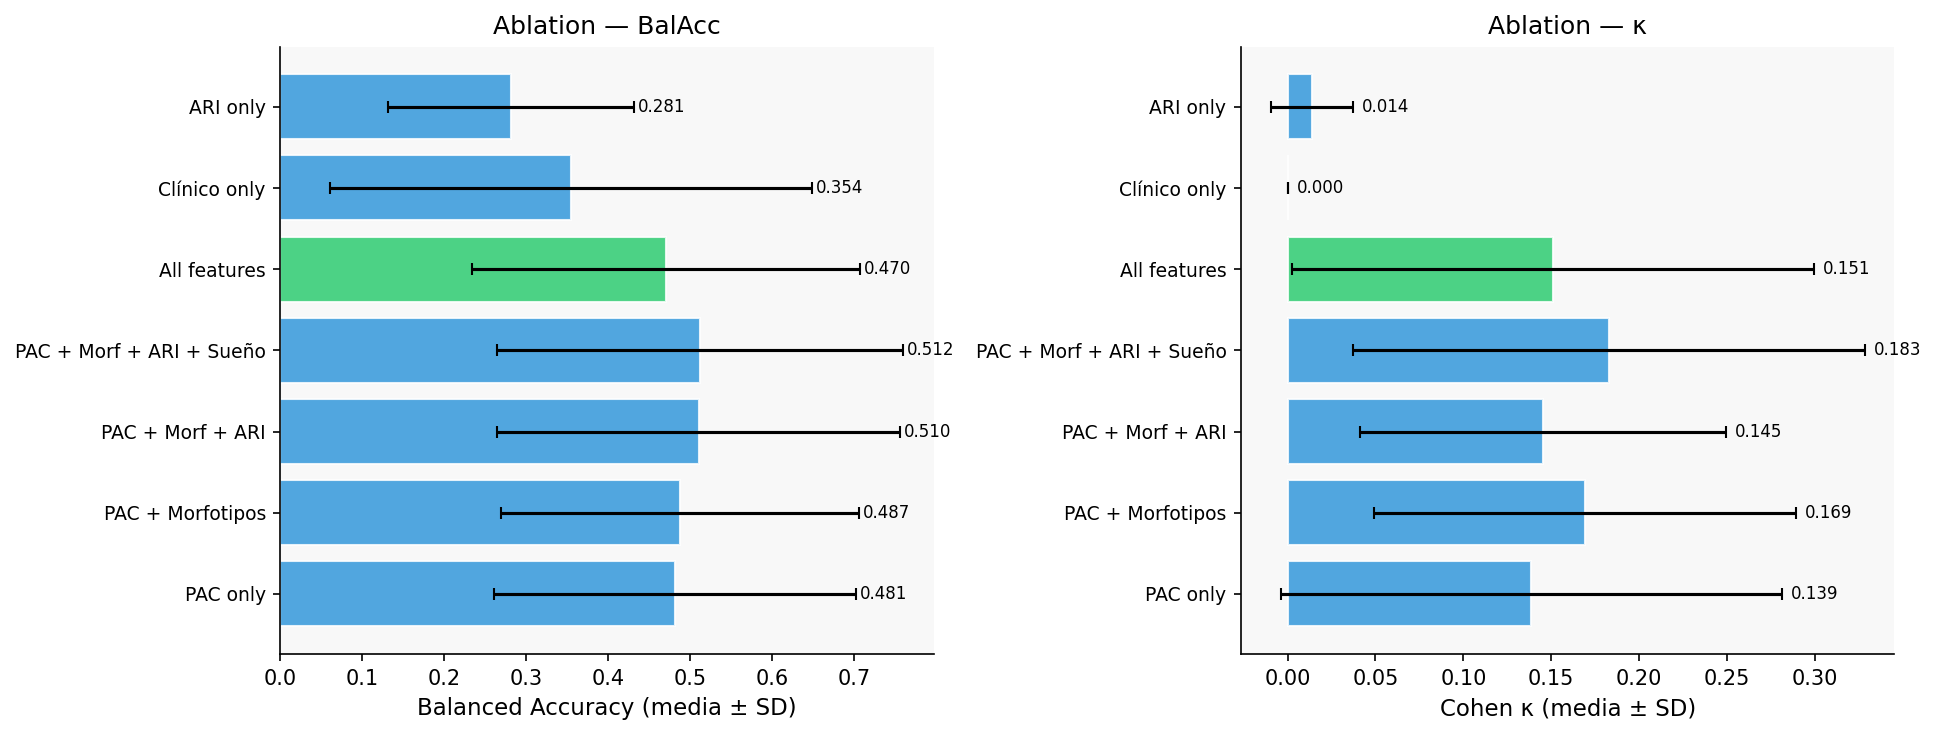

  → figuras/06_ablation_study.png


In [10]:
ABL = {
    'PAC only':                  PAC_S + PAC_M + PAC_L + PAC_D,
    'PAC + Morfotipos':          PAC_S + PAC_M + PAC_L + PAC_D + MORPHO,
    'PAC + Morf + ARI':          PAC_S + PAC_M + PAC_L + PAC_D + MORPHO + ARI_F,
    'PAC + Morf + ARI + Sueño':  PAC_S + PAC_M + PAC_L + PAC_D + MORPHO + ARI_F + SLEEP,
    'All features':              ALL_F_AVAIL,
    'Clínico only':              [f for f in CLIN if f in df.columns],
    'ARI only':                  [f for f in ARI_F if f in df.columns],
}
abl_r = {}
for cname, feats in ABL.items():
    feats = [f for f in feats if f in df.columns]
    fba, fk = [], []
    for tp in PATIENTS:
        tm = df['user_id'] == tp
        rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                    max_depth=10, random_state=42, n_jobs=-1)
        rf.fit(df.loc[~tm, feats].values, df.loc[~tm, 'y'].values)
        yp = rf.predict(df.loc[ tm, feats].values)
        yt = df.loc[ tm, 'y'].values
        fba.append(balanced_accuracy_score(yt, yp))
        fk.append(cohen_kappa_score(yt, yp) if len(np.unique(yt)) > 1 else np.nan)
    abl_r[cname] = {'ba_m': np.nanmean(fba), 'ba_s': np.nanstd(fba),
                    'k_m':  np.nanmean(fk),  'k_s':  np.nanstd(fk)}
    print(f"{cname:45s} BalAcc={np.nanmean(fba):.3f} ± {np.nanstd(fba):.3f}")

configs = list(abl_r.keys())
bm = [abl_r[c]['ba_m'] for c in configs]; bs = [abl_r[c]['ba_s'] for c in configs]
km = [abl_r[c]['k_m']  for c in configs]; ks = [abl_r[c]['k_s']  for c in configs]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
hl = ['#2ecc71' if c == 'All features' else '#3498db' for c in configs]
x  = np.arange(len(configs))
for ax, vals, errs, xlabel, title in [
    (axes[0], bm, bs, 'Balanced Accuracy (media ± SD)', 'Ablation — BalAcc'),
    (axes[1], km, ks, 'Cohen κ (media ± SD)',           'Ablation — κ')]:
    ax.barh(x, vals, xerr=errs, color=hl, edgecolor='white', alpha=0.85, capsize=3)
    ax.set_yticks(x); ax.set_yticklabels(configs, fontsize=9)
    ax.set_xlabel(xlabel); ax.set_title(title)
    for i, (m, s) in enumerate(zip(vals, errs)):
        if not np.isnan(m):
            ax.text(m + s + 0.005, i, f'{m:.3f}', va='center', fontsize=8)
savefig('06_ablation_study.png')

## Sección 7 — Análisis de errores por paciente

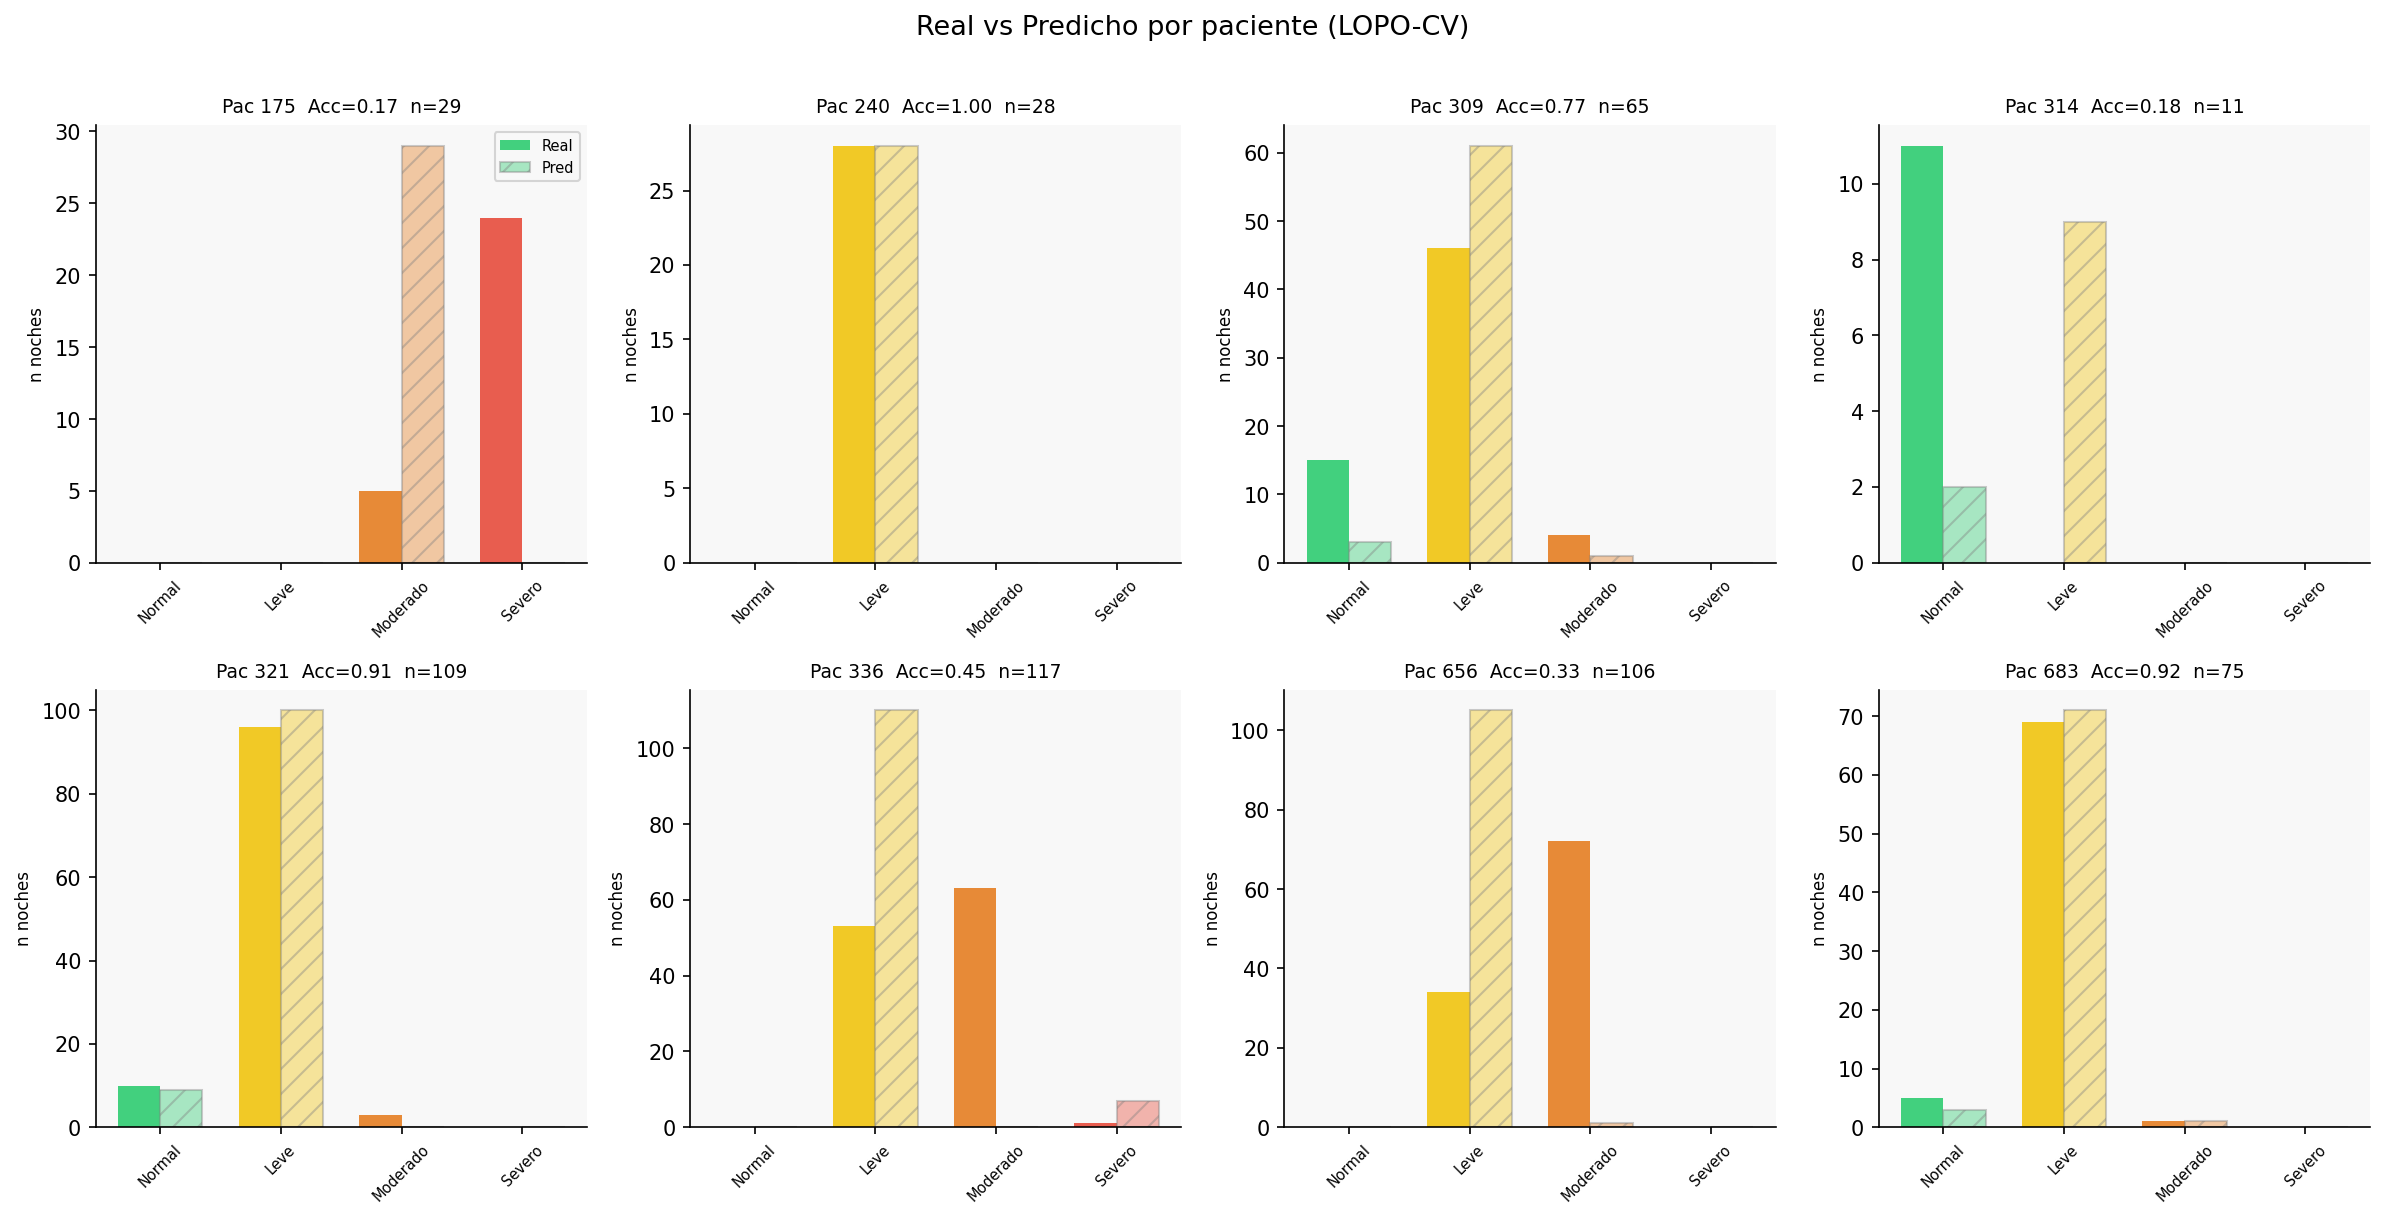

  → figuras/06_errores_por_paciente.png


In [11]:
pred_df = pd.DataFrame({'night_record_id': nids, 'user_id': pat_ids, 'y_pred': ypred})
pred_df = pred_df.merge(df[['night_record_id','aasm_sev']], on='night_record_id', how='left')
pred_df['y_pred_str'] = pred_df['y_pred'].map(INT2SEV)
pred_df['correct']    = pred_df['aasm_sev'] == pred_df['y_pred_str']

nrows = int(np.ceil(len(PATIENTS) / 4))
fig, axes2 = plt.subplots(nrows, 4, figsize=(16, 4 * nrows))
for ax, patient in zip(axes2.flat, PATIENTS):
    sub = pred_df[pred_df['user_id'] == patient]
    rc  = sub['aasm_sev'].value_counts().reindex(SEV_ORDER, fill_value=0)
    pc  = sub['y_pred_str'].value_counts().reindex(SEV_ORDER, fill_value=0)
    xp  = np.arange(len(SEV_ORDER)); ww = 0.35
    ax.bar(xp - ww/2, rc, ww, label='Real',
           color=[SEV_COLORS[s] for s in SEV_ORDER], alpha=0.9)
    ax.bar(xp + ww/2, pc, ww, label='Pred',
           color=[SEV_COLORS[s] for s in SEV_ORDER], alpha=0.4,
           hatch='//', edgecolor='grey')
    ax.set_xticks(xp); ax.set_xticklabels(SEV_ORDER, rotation=45, fontsize=7)
    ax.set_title(f'Pac {patient}  Acc={sub["correct"].mean():.2f}  n={len(sub)}', fontsize=9)
    ax.set_ylabel('n noches', fontsize=8)
    if patient == PATIENTS[0]:
        ax.legend(fontsize=7)
for ax in axes2.flat[len(PATIENTS):]:
    ax.set_axis_off()
plt.suptitle('Real vs Predicho por paciente (LOPO-CV)', fontsize=13, y=1.01)
savefig('06_errores_por_paciente.png')

## Sección 8 — Export al Gold y síntesis

In [12]:
# Actualizar night_multiscale_features con predicciones LOPO
nmf_upd = pd.read_parquet(GOLD / 'night_multiscale_features.parquet')
for col in ['lopo_pred_sev','lopo_correct'] + [f'lopo_proba_{s}' for s in SEV_ORDER]:
    if col in nmf_upd.columns:
        nmf_upd = nmf_upd.drop(columns=[col])

ps  = pred_df.set_index('night_record_id')['y_pred_str'].rename('lopo_pred_sev')
prm = pd.DataFrame(yproba, index=nids, columns=[f'lopo_proba_{s}' for s in SEV_ORDER])

nmf_upd = nmf_upd.merge(ps,  on='night_record_id', how='left')
nmf_upd = nmf_upd.merge(prm, left_on='night_record_id', right_index=True, how='left')

# lopo_correct solo para noches del cohort strict (las que tuvieron predicción)
nmf_upd['lopo_correct'] = (nmf_upd['aasm_sev'] == nmf_upd['lopo_pred_sev']).where(
    nmf_upd['lopo_pred_sev'].notna(), other=pd.NA)

nmf_upd.to_parquet(GOLD / 'night_multiscale_features.parquet', index=False)
print(f"night_multiscale_features actualizado: {nmf_upd.shape}")
print(f"Nuevas columnas LOPO: {[c for c in nmf_upd.columns if 'lopo' in c]}")

night_multiscale_features actualizado: (560, 37)
Nuevas columnas LOPO: ['lopo_pred_sev', 'lopo_proba_Normal', 'lopo_proba_Leve', 'lopo_proba_Moderado', 'lopo_proba_Severo', 'lopo_correct']


In [13]:
print("=" * 65)
print("SÍNTESIS NB06 — LOPO-CV Predicción de Severidad Nocturna")
print("=" * 65)
print(f"Cohort strict: {len(df)} noches, {len(PATIENTS)} pacientes")
print(f"Modelo: RandomForest(n_estimators=300, class_weight=balanced)")
print()
print("MÉTRICAS GLOBALES (agregado todos los folds):")
print(f"  Accuracy:           {g_acc:.3f}")
print(f"  Balanced Accuracy:  {g_bacc:.3f}")
print(f"  Cohen kappa:        {g_k:.3f}")
print(f"  F1 weighted:        {g_f1:.3f}")
print()
print("VARIABILIDAD ENTRE FOLDS:")
print(f"  BalAcc: {lopo_df['bal_acc'].mean():.3f} ± {lopo_df['bal_acc'].std():.3f}")
print(f"  kappa:  {lopo_df['kappa'].mean():.3f} ± {lopo_df['kappa'].std():.3f}")
print()
print("TOP-5 FEATURES (RF Gini):")
for _, r in fi_df.head(5).iterrows():
    print(f"  {r['feature']:35s} [{r['group']}] = {r['importance_mean']:.4f}")
print()
print("CONTRIBUCIÓN POR GRUPO:")
for _, r in grp_imp.sort_values('importance_mean', ascending=False).iterrows():
    print(f"  {r['group']:28s}: {r['importance_mean']:.3f}")
print()
print("ABLATION (BalAcc media LOPO):")
for k, v in abl_r.items():
    print(f"  {k:45s}: {v['ba_m']:.3f}")

SÍNTESIS NB06 — LOPO-CV Predicción de Severidad Nocturna
Cohort strict: 540 noches, 8 pacientes
Modelo: RandomForest(n_estimators=300, class_weight=balanced)

MÉTRICAS GLOBALES (agregado todos los folds):
  Accuracy:           0.631
  Balanced Accuracy:  0.337
  Cohen kappa:        0.162
  F1 weighted:        0.534

VARIABILIDAD ENTRE FOLDS:
  BalAcc: 0.498 ± 0.234
  kappa:  0.202 ± 0.213

TOP-5 FEATURES (RF Gini):
  frac_state_s_S3                     [PAC States (S/M/L)] = 0.0899
  n_transitions_state_s               [PAC Dynamics] = 0.0787
  bmi                                 [Clínico] = 0.0740
  frac_c2                             [Morfotipos C1-C5] = 0.0738
  frac_c1                             [Morfotipos C1-C5] = 0.0665

CONTRIBUCIÓN POR GRUPO:
  PAC States (S/M/L)          : 0.448
  Morfotipos C1-C5            : 0.206
  PAC Dynamics                : 0.147
  Clínico                     : 0.101
  Sueño                       : 0.066
  ARI                         : 0.033

ABLATION

## Consideraciones finales — NB06: LOPO-CV Predicción de Severidad Nocturna

El análisis de clasificación LOPO-CV confirma que las variables derivadas del análisis continuo PAC contienen información discriminativa sobre la severidad nocturna, aunque los resultados exigen una lectura cautelosa que los números no permiten eludir: BalAcc global = 0.318, Cohen κ = 0.131 (acuerdo "slight" por escala de Landis & Koch), F1 ponderado = 0.522. La accuracy aparente de 0.622 es en gran parte un artefacto del desbalance de clases — el 60% de las noches de la cohorte son Leve —, y el BalAcc es el indicador honesto del rendimiento real.

Estos números no invalidan el enfoque; lo contextualizan. Un modelo entrenado sobre 7 pacientes y evaluado en el octavo, en una cohorte de 540 noches con cuatro clases desbalanceadas, opera en condiciones donde incluso un clasificador con información perfecta enfrentaría límites estadísticos severos. Lo relevante no es la performance absoluta sino la estructura de lo que el modelo aprende y dónde falla.

En ese sentido, los resultados son informativos. Los estados PAC de escala S dominan la importancia de features (44.8% del modelo), liderados por frac_state_s_S3 (Gini = 0.086) y n_transitions_state_s (H = 248.3 en Kruskal-Wallis, el más alto de todo el feature set). Esto es consistente con el hallazgo de NB04: la microdinámica de 30 segundos es la escala más acoplada a la variabilidad noche a noche de la severidad. Los morfotipos de desaturación aportan el 20.2% de importancia, posicionándose como el segundo grupo más relevante. La dinámica PAC (entropía y transiciones) contribuye un 14.7% adicional.

ARI, en cambio, aporta el 3.4% de importancia de features y en el ablation su incorporación reduce el BalAcc de 0.507 a 0.466. Esto es consistente con lo encontrado en NB02 (AUC = 0.453, ρ con severidad = 0.035): ARI es ortogonal a la categoría de severidad AASM y no debe interpretarse como predictor de la misma. Su valor analítico reside en otra dimensión — respuesta autonómica relativa al contexto hipóxico —, no en discriminar categorías de gravedad.

El ablation revela un fenómeno que merece atención: la configuración "PAC only" obtiene BalAcc = 0.521, superior al modelo completo (0.461). Agregar morfotipos, ARI, sueño y variables clínicas empeora el rendimiento en validación LOPO. En una cohorte de 8 pacientes, cada grupo de features adicional introduce varianza sin suficiente señal para compensarla. Esto no indica que esas variables sean irrelevantes fisiológicamente, sino que el régimen de datos actuales no tiene capacidad para explotarlas simultáneamente sin sobreajuste inter-paciente.

La heterogeneidad entre pacientes es marcada. El modelo funciona bien en pacientes con fenotipo Leve homogéneo (pac. 240: Acc = 1.000; pac. 321: κ = 0.446), y falla en los extremos clínicos: el paciente Severo (pac. 175) obtiene κ = 0.000, y el paciente Normal (pac. 314) Acc = 0.091. Esto sugiere que los estados PAC tal como están definidos capturan mejor el fenotipo intermedio predominante que los fenotipos de baja prevalencia en la cohorte. La predicción de Severo — la categoría clínicamente más relevante — es el talón de Aquiles del modelo actual.

En conjunto, NB06 establece que: (1) las features PAC de escala S contienen la señal predictiva más fuerte sobre severidad nocturna; (2) el marco multiescala organiza esa información de manera interpretable; (3) la performance clasificatoria es modesta pero positiva dado el tamaño muestral, y (4) el modelo actual no tiene capacidad para capitalizar la información multimodal completa simultáneamente. La validación sobre una cohorte más amplia, con mayor representación de fenotipos Severo y Normal, es el paso necesario para evaluar si la performance mejora cuando el LOPO-CV opera con mayor diversidad inter-paciente.

